# Simulated Annealing for Minimization of f(x) = x^2 - 8x + 20

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

### Define the objective function

In [2]:
def f(x):
    return x**2 - 8*x + 20

x0 = 2
print("f(x0) =", f(x0))

f(x0) = 8


### Generate the neighbour and evaluate the first move

In [3]:
x_prime = x0 + 1
delta_f = f(x_prime) - f(x0)
print("Neighbour x' =", x_prime, " f(x') =", f(x_prime), " Delta f =", delta_f)
print("Delta f <= 0, so this move is accepted unconditionally")

Neighbour x' = 3  f(x') = 5  Delta f = -3
Delta f <= 0, so this move is accepted unconditionally


### Set up Simulated Annealing parameters

In [4]:
T = 12
alpha = 0.6
T_min = 1
given_randoms = [0.25, 0.70, 0.35, 0.85]

### Run Simulated Annealing for four iterations, recording every quantity

In [5]:
x = x0
r_pointer = 0
best_x, best_f = x, f(x)
records = []

for iteration in range(1, 5):
    fx = f(x)
    x_before = x
    xp = x + 1
    fxp = f(xp)
    df = fxp - fx

    if df <= 0:
        P = 1.0
        r_used = None
        decision = "Accept (Delta f <= 0)"
        accept = True
    else:
        P = math.exp(-df / T)
        r_used = given_randoms[r_pointer]
        r_pointer += 1
        accept = r_used < P
        decision = "Accept (r < P)" if accept else "Reject (r >= P)"

    if accept:
        x = xp

    if f(x) < best_f:
        best_x, best_f = x, f(x)

    records.append({
        "Iteration": iteration, "T": T, "x (before move)": x_before, "Neighbour x'": xp,
        "f(x)": fx, "f(x')": fxp, "Delta f": df,
        "P": round(P, 4), "r": r_used, "Decision": decision,
        "Best x": best_x, "Best f(x)": best_f
    })

    print(f"Iteration {iteration}: T={T}, x={x_before}, x'={xp}, "
          f"f(x)={fx}, f(x')={fxp}, Delta f={df}, P={round(P,4)}, r={r_used}, {decision}")
    print("  -> new current x =", x, "  best so far: x =", best_x, "f(x) =", best_f)

    T = T * alpha

print()
print("Final current x:", x, " f(x) =", f(x))
print("Best solution found: x =", best_x, " f(x) =", best_f)

Iteration 1: T=12, x=2, x'=3, f(x)=8, f(x')=5, Delta f=-3, P=1.0, r=None, Accept (Delta f <= 0)
  -> new current x = 3   best so far: x = 3 f(x) = 5
Iteration 2: T=7.199999999999999, x=3, x'=4, f(x)=5, f(x')=4, Delta f=-1, P=1.0, r=None, Accept (Delta f <= 0)
  -> new current x = 4   best so far: x = 4 f(x) = 4
Iteration 3: T=4.319999999999999, x=4, x'=5, f(x)=4, f(x')=5, Delta f=1, P=0.7934, r=0.25, Accept (r < P)
  -> new current x = 5   best so far: x = 4 f(x) = 4
Iteration 4: T=2.5919999999999996, x=5, x'=6, f(x)=5, f(x')=8, Delta f=3, P=0.3143, r=0.7, Reject (r >= P)
  -> new current x = 5   best so far: x = 4 f(x) = 4

Final current x: 5  f(x) = 5
Best solution found: x = 4  f(x) = 4


### Build the complete iteration table

In [6]:
table = pd.DataFrame(records)[["Iteration", "T", "x (before move)", "Neighbour x'", "f(x)", "f(x')", "Delta f", "P", "r", "Decision", "Best x", "Best f(x)"]]
print(table.to_string(index=False))

 Iteration      T  x (before move)  Neighbour x'  f(x)  f(x')  Delta f      P    r              Decision  Best x  Best f(x)
         1 12.000                2             3     8      5       -3 1.0000  NaN Accept (Delta f <= 0)       3          5
         2  7.200                3             4     5      4       -1 1.0000  NaN Accept (Delta f <= 0)       4          4
         3  4.320                4             5     4      5        1 0.7934 0.25        Accept (r < P)       4          4
         4  2.592                5             6     5      8        3 0.3143 0.70       Reject (r >= P)       4          4


### Verify analytically

In [7]:
x_star = 4
print("Analytical minimum at x =", x_star, " f(x) =", f(x_star))
print("SA best solution matches analytical minimum:", best_x == x_star and best_f == f(x_star))

Analytical minimum at x = 4  f(x) = 4
SA best solution matches analytical minimum: True


### Plot convergence of best-so-far value

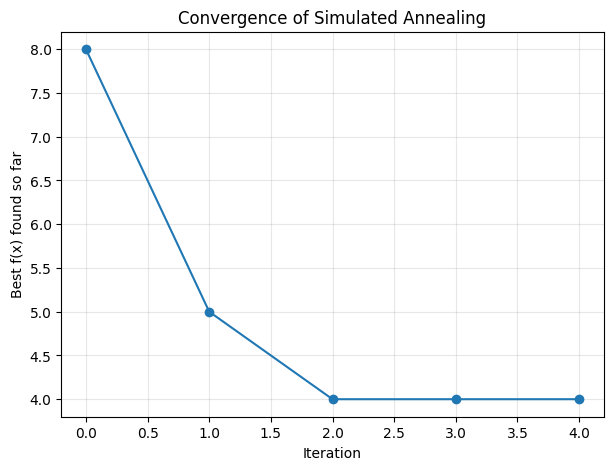

In [8]:
best_curve = [f(x0)]
running_best = f(x0)
for rec in records:
    running_best = min(running_best, rec["Best f(x)"])
    best_curve.append(running_best)

plt.figure(figsize=(7, 5))
plt.plot(range(len(best_curve)), best_curve, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Best f(x) found so far")
plt.title("Convergence of Simulated Annealing")
plt.grid(alpha=0.3)
plt.show()